# The inverse renormalization group with convolutional networks
### A worked example for the two-dimensional Ising model

*Companion notebook to the repository [ML-for-iRG](https://github.com/louis-spatscheck/ML-for-iRG) and the bachelor thesis "Machine Learning for the Inverse Renormalization Group" (University of Stuttgart, Institute for Computational Physics, 2024).*

**Abstract.** This notebook walks through the complete workflow of the repository on a small scale. We (i) generate an ensemble of Ising configurations with the C++ Metropolis simulator, (ii) coarse-grain it with the majority rule, (iii) train a convolutional U-Net to *invert* this coarse-graining, and (iv) apply the learned inverse transformation iteratively to generate configurations on lattices that we never simulate. We compare the generated ensembles with direct simulations and estimate the finite-size-scaling exponent $\beta/\nu$ from them, whose exact value is $1/8$. The presentation is intended to be interactive: working with the notebook, and changing the parameters in Sec. III B, is recommended.

Readers unfamiliar with the notebook format should read this document as a single annotated program, in which all code is executed sequentially from start to finish without clearing the scope. The stored outputs come from one run on a single CPU core (about 10 minutes); a GPU is used automatically if available.

## I. INTRODUCTION

Near a continuous phase transition the correlation length diverges and fluctuations occur on all length scales. The **renormalization group** (RG) turns this observation into a tool: *coarse-graining* a configuration removes short-distance details, and the way observables change under repeated coarse-graining reveals the critical exponents of the transition.

The **inverse RG** runs this process backwards. Starting from a small system, a *learned* transformation adds the missing short-distance degrees of freedom and thereby produces a configuration of a system twice as large. Applied repeatedly, it can generate very large lattices at the critical point. This is attractive because Metropolis simulations suffer from *critical slowing down*: the cost of one independent sample grows like $L^{2+z}$ with $z \approx 2.17$, whereas applying a neural network only costs $\mathcal O(L^2)$ (one pass over the lattice) per step.

The aim of this notebook is to make every step of that pipeline visible:

1. **Setup** — imports, helper functions and all parameters in one place (Sec. III).
2. **Generating an ensemble** — Metropolis simulation, equilibration and autocorrelation, decorrelated samples (Sec. IV).
3. **The forward RG** — majority-rule coarse-graining and the resulting training pairs (Sec. V).
4. **Learning the inverse transformation** — a U-Net trained on these pairs (Sec. VI).
5. **Using it** — from the network output to spins, and iterating the transformation (Sec. VII).
6. **Does it reproduce the physics?** — comparison with direct simulations and the scaling exponent $\beta/\nu$ (Sec. VIII).

## II. BACKGROUND AND NOTATION

**The model.** We consider the ferromagnetic Ising model on an $L \times L$ square lattice with periodic boundary conditions. Spins $s_i = \pm 1$ interact with their nearest neighbours,

$$H(\mathbf s) = -\sum_{\langle ij \rangle} s_i s_j , \qquad p(\mathbf s) = \frac{e^{-\beta H(\mathbf s)}}{Z}, \tag{1}$$

where we absorbed the coupling into the inverse temperature $\beta$ (called `betaJ` in the code). The model has a continuous phase transition at the exactly known value

$$\beta_c = \tfrac12 \ln\!\big(1+\sqrt2\big) \approx 0.4407 . \tag{2}$$

**Observables.** The magnetization per site and the susceptibility of a finite lattice are

$$m(\mathbf s) = \frac{1}{L^2}\sum_i s_i , \qquad \chi = L^2\left(\langle m^2\rangle - \langle |m| \rangle^2\right). \tag{3}$$

At $\beta_c$ finite-size scaling predicts power laws in the linear size $L$,

$$\langle |m| \rangle \propto L^{-\beta/\nu} , \qquad \chi \propto L^{\gamma/\nu}, \qquad \frac{\beta}{\nu} = \frac18, \quad \frac{\gamma}{\nu} = \frac74 . \tag{4}$$

**The forward RG.** We use the *majority rule* with scale factor $b=2$: every $2\times2$ block $B$ of the lattice is replaced by a single spin,

$$s'_B = \operatorname{sign}\Big(\sum_{i \in B} s_i\Big), \tag{5}$$

with ties (two up, two down spins) broken at random. This maps a configuration $\mathbf s$ of size $L\times L$ to a configuration $\mathbf s' = R(\mathbf s)$ of size $L/2 \times L/2$. Note that $R$ is applied to *configurations*; the induced map on the distribution corresponds to a change $\beta \to \beta'$ that is very small close to the fixed point.

**The inverse RG.** The map $R$ cannot be inverted: a $2\times2$ block has 16 microstates but the coarse spin only records 2 possibilities. We therefore *learn* a network $f_\theta$ that predicts a fine configuration from a coarse one by minimizing the mean squared error over an ensemble,

$$\mathcal L(\theta) = \Big\langle \big\| f_\theta(\mathbf s') - \mathbf s \big\|^2 \Big\rangle_{\mathbf s \sim p} . \tag{6}$$

> **NOTE:** The minimizer of Eq. (6) is the *conditional expectation* $f^*(\mathbf s') = \mathbb E[\mathbf s \mid \mathbf s']$. It is a real-valued field with entries in $(-1,1)$, not a configuration of $\pm1$ spins. Turning it into spins requires an additional discretization step (Sec. VII A), and it is this step, not the network alone, that decides how physical the generated configurations are.

**Notation.**

* $L$ — linear lattice size; $\mathbf s \in \{\pm1\}^{L\times L}$ — a configuration ("fine"); $\mathbf s' = R(\mathbf s)$ — its coarse-grained version ("coarse"), of size $L/2$.
* $\beta$ — inverse temperature; $\beta_0$ — the value at which we generate the ensemble.
* One **sweep** is $L^2$ attempted spin flips. $\tau_\mathrm{int}$ — integrated autocorrelation time in sweeps.
* $f_\theta$ — the neural network. To keep the ReLU activations effective, inputs and targets are shifted from $\{-1,+1\}$ to $\{0,2\}$ by adding 1; outputs are shifted back before use.

## III. SETUP

### A. Imports and helper functions

We begin by importing the packages used throughout. The notebook needs the repository installed (`pip install -e ".[ml]"` from the repository root, which also compiles the C++ simulator). Readers may safely execute and skip over the remainder of this section.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib.ticker import MaxNLocator, NullFormatter, NullLocator

from invrg import autocorr
from invrg.constants import BETA_C_EXACT, BETA_OVER_NU
from invrg.ising import IsingModel
from invrg.models import UNet
from invrg.rg import majority_rule

print(f"TORCH VERSION: {torch.__version__}")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 10, "axes.labelsize": 10})

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"TORCH DEVICE: {torch_device}")

TORCH VERSION: 2.14.0+cu130
TORCH DEVICE: cpu


Below are small utilities. `magnetization` and `nn_correlation` measure two properties of an ensemble of configurations: $|m|$ from Eq. (3), and the nearest-neighbour correlation $\langle s_i s_j\rangle$, which is a direct measure of the short-range structure (it is proportional to the energy per site). `show_configs` draws spin configurations.

In [2]:
def grab(tensor):
    """Detach a tensor from the computational graph and convert it to a numpy array."""
    return tensor.detach().cpu().numpy()


def magnetization(configs):
    """|m| of every configuration in an array of shape (N, L, L)."""
    return np.abs(np.asarray(configs, dtype=float).mean(axis=(1, 2)))


def nn_correlation(configs):
    """Nearest-neighbour correlation <s_i s_j> of every configuration in an array of shape (N, L, L)."""
    c = np.asarray(configs, dtype=float)
    return 0.5 * ((c * np.roll(c, 1, axis=1)).mean(axis=(1, 2)) + (c * np.roll(c, 1, axis=2)).mean(axis=(1, 2)))


def show_configs(configs, titles=None, ncols=None, size=2.1, cmap="gray", vmin=-1, vmax=1):
    """Draw a list of configurations (2D arrays) next to each other."""
    ncols = ncols or len(configs)
    nrows = int(np.ceil(len(configs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(size * ncols, size * nrows), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for i, (ax, config) in enumerate(zip(axes.flat, configs)):
        ax.imshow(config, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
        if titles is not None:
            ax.set_title(titles[i])
    plt.tight_layout()
    plt.show()

### B. Summary of all parameters

For convenience, all parameters that determine the run are collected in the cell below. The defaults are chosen such that the notebook runs in about 10 minutes on a CPU, which is *orders of magnitude* less computation than the thesis used (see Sec. IX for the thesis values).

In [3]:
# --- physics -------------------------------------------------------------------------
beta0 = 0.44          # inverse temperature of the ensemble (critical value: 0.4407)
L_fine = 32           # size of the original lattices used for training; the coarse ones have L_fine / 2

# --- training ensemble ---------------------------------------------------------------
n_configs = 1000      # decorrelated configurations of size L_fine
n_val = 200           # validation configurations (taken from the end, never used for training)

# --- training the network ------------------------------------------------------------
epochs = 3            # passes over the (augmented) training set
batch_size = 16
learning_rate = 5e-4
use_pretrained = False  # load the weights saved by a previous run (folder _cache) instead of training

# --- generation and comparison with direct simulations -------------------------------
n_test = 200          # configurations per lattice size in the test ensembles
n_steps = 3           # number of applications of the inverse RG: L_fine/2 -> L_fine -> 2 L_fine -> 4 L_fine
seed = 2024

The size $L_\mathrm{fine}/2 = 16$ is the smallest lattice that we simulate directly for the final comparison. With `n_steps = 3` the learned transformation takes us to $4 L_\mathrm{fine} = 128$, a lattice that we never simulate. The default is $\beta_0 = 0.44$, very slightly below $\beta_c$.

## IV. GENERATING AN ENSEMBLE

### A. Metropolis simulation

We sample the distribution (1) with the Metropolis algorithm: a randomly chosen spin is flipped and the flip is accepted with probability $\min(1, e^{-\beta\Delta H})$. The repository provides a C++ implementation (`invrg.ising.IsingModel`) wrapped with Cython. Every model instance owns its random number generator, seeded by the argument `seed`.

The simulation starts from a *random* configuration, which corresponds to $\beta=0$. It therefore has to relax into equilibrium first. We record $|m|$ and the energy per site $e = H/L^2$ after every sweep.

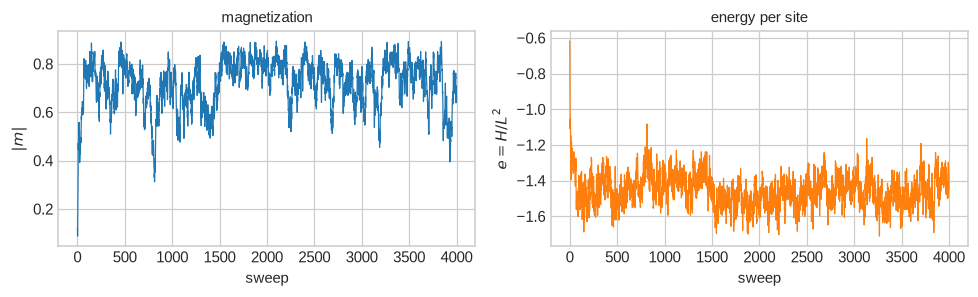

In [4]:
np.random.seed(seed)       # tie-breaking in the majority rule (Sec. V)
torch.manual_seed(seed)    # network initialization, batches and stochastic rounding

L = L_fine
sim = IsingModel(beta0, L, seed=seed)

n_sweeps = 20_000
m_series, e_series = np.empty(n_sweeps), np.empty(n_sweeps)
for t in range(n_sweeps):
    sim.try_many_random_flips(L * L)          # one sweep = L^2 attempted flips
    m_series[t] = sim.magnetization()
    e_series[t] = sim.energy() / L**2

fig, ax = plt.subplots(1, 2, figsize=(9, 2.8))
ax[0].plot(np.abs(m_series[:4000]), lw=0.8)
ax[0].set(xlabel="sweep", ylabel=r"$|m|$", title="magnetization")
ax[1].plot(e_series[:4000], lw=0.8, c="C1")
ax[1].set(xlabel="sweep", ylabel=r"$e = H/L^2$", title="energy per site")
plt.tight_layout()
plt.show()

Both quantities leave their initial values within about 100 sweeps and then fluctuate around stationary values; the magnetization shows large, slow excursions, a first hint of the strong correlations discussed next. We discard the first 2000 sweeps as *equilibration*, which is generous.

### B. Autocorrelation

Consecutive Metropolis configurations are strongly correlated, in particular close to the critical point. The normalized autocorrelation function $A(t)$ of an observable decays roughly exponentially, and the **integrated autocorrelation time**

$$\tau_\mathrm{int} = \frac12 + \sum_{t \ge 1} A(t) \tag{7}$$

counts the number of sweeps after which two measurements are effectively independent. The statistical error of a mean over $N$ correlated measurements is $\sqrt{2\tau_\mathrm{int}/N}$ times the naive one. The function `invrg.autocorr.calc_error` computes $\tau_\mathrm{int}$ (with an automatic cut-off of the sum) and the corrected error.

<|m|> = 0.6548 +- 0.0236,   tau_int = 152.4 sweeps


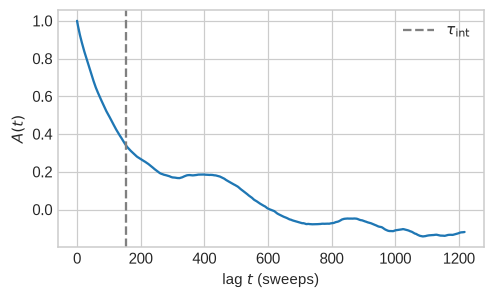

In [5]:
warmup = 2000
abs_m = np.abs(m_series[warmup:])

acf = autocorr.autocorrelation(abs_m)
mean_m, err_m, tau_int = autocorr.calc_error(abs_m)
print(f"<|m|> = {mean_m:.4f} +- {err_m:.4f},   tau_int = {tau_int:.1f} sweeps")

plt.figure(figsize=(5, 2.8))
lags = np.arange(int(8 * tau_int))
plt.plot(lags, acf[:len(lags)])
plt.axvline(tau_int, ls="--", c="gray", label=r"$\tau_\mathrm{int}$")
plt.xlabel("lag $t$ (sweeps)")
plt.ylabel("$A(t)$")
plt.legend()
plt.show()

### C. Decorrelated samples

Training on strongly correlated configurations would waste computation on near-duplicates, so we keep one configuration every $2\tau_\mathrm{int}$ sweeps. (The thesis samples at intervals of the autocorrelation time.) We simply continue the chain from where we stopped.

1000 configurations, one every 305 sweeps (305000 sweeps in 14 s)
<|m|> from the ensemble: 0.6403 +- 0.0059   (naive error of 1000 independent samples)


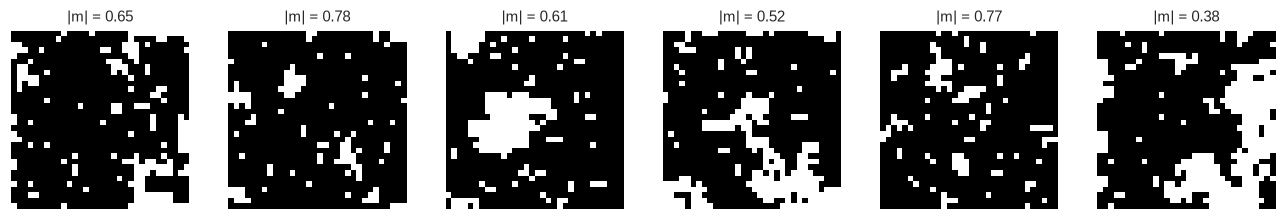

In [6]:
spacing = int(np.ceil(2 * tau_int))
fine = np.empty((n_configs, L, L), dtype=np.int8)
t_start = time.time()
for i in range(n_configs):
    for _ in range(spacing):
        sim.try_many_random_flips(L * L)
    fine[i] = sim.as_numpy()
print(f"{n_configs} configurations, one every {spacing} sweeps ({n_configs * spacing} sweeps in {time.time() - t_start:.0f} s)")

m_ens = magnetization(fine)
print(f"<|m|> from the ensemble: {m_ens.mean():.4f} +- {m_ens.std() / np.sqrt(n_configs):.4f}   (naive error of {n_configs} independent samples)")
show_configs(fine[:6], titles=[f"|m| = {m:.2f}" for m in m_ens[:6]], size=2)

Near $\beta_c$ the configurations show ordered domains of all sizes. The ensemble mean of $|m|$ agrees with the mean of the full time series above, so the decorrelated ensemble represents the distribution well.

> **NOTE:** The pipeline below never needs more than the ensemble `fine`. Everything else is derived from it.

## V. THE FORWARD RG: TRAINING PAIRS

### A. Coarse-graining with the majority rule

The learning problem needs pairs $(\mathbf s', \mathbf s)$ of a coarse and the matching fine configuration. The coarse ones follow from the fine ones by the majority rule (5), implemented in `invrg.rg.majority_rule`. We first look at what the transformation does to a single configuration, applying it repeatedly and drawing every level at the same size.

Processing configurations:   0%|          | 0/1000 [00:00<?, ?it/s]

Processing configurations: 100%|██████████| 1000/1000 [00:00<00:00, 56127.61it/s]

Processing time: 0.02 seconds


Processing configurations:   0%|          | 0/1 [00:00<?, ?it/s]

Processing configurations: 100%|██████████| 1/1 [00:00<00:00, 6105.25it/s]

...

Processing configurations: 100%|██████████| 1/1 [00:00<00:00, 6808.94it/s]

Processing time: 0.00 seconds


Processing configurations:   0%|          | 0/1 [00:00<?, ?it/s]

Processing configurations: 100%|██████████| 1/1 [00:00<00:00, 7013.89it/s]

Processing time: 0.00 seconds


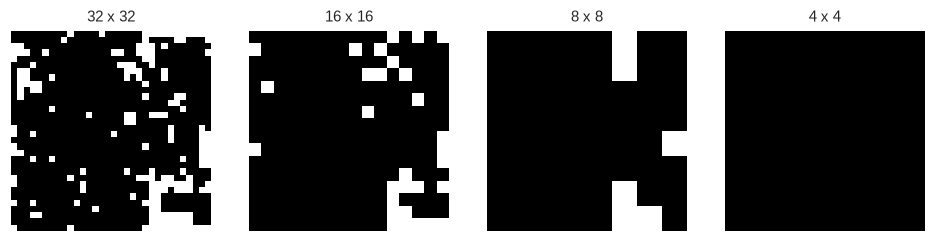

In [7]:
coarse = majority_rule(fine, L_fine)      # (n_configs, L_fine/2, L_fine/2), spins +-1 as floats

levels = [fine[0]]
for size in (L_fine, L_fine // 2, L_fine // 4):
    levels.append(majority_rule(levels[-1][None], size)[0])
show_configs(levels, titles=[f"{l.shape[0]} x {l.shape[0]}" for l in levels], size=2.2)

Each step halves the linear size and removes detail while the large-scale domain structure is preserved. This is the information the inverse transformation has to work with. Let us also compare the magnetization before and after one coarse-graining step, and the short-range order.

In [8]:
summary = pd.DataFrame({
    "lattice size": [L_fine, L_fine // 2],
    "<|m|>": [magnetization(fine).mean(), magnetization(coarse).mean()],
    "<s_i s_j>": [nn_correlation(fine).mean(), nn_correlation(coarse).mean()],
}, index=["fine", "coarse (majority rule)"])
print(f"ratio of the magnetizations: {summary.loc['coarse (majority rule)', '<|m|>'] / summary.loc['fine', '<|m|>']:.3f}   (expected 2^(1/8) = {2 ** BETA_OVER_NU:.3f})")
summary.round(4)

ratio of the magnetizations: 1.086   (expected 2^(1/8) = 1.091)


,lattice size,<|m|>,<s_i s_j>
fine,32,0.6403,0.7136
coarse (majority rule),16,0.6956,0.7083


Two things are worth noticing. The nearest-neighbour correlation is essentially unchanged by the coarse-graining: at the critical point the coarse-grained configuration looks statistically like a configuration of a smaller system at almost the same temperature, which is the fixed-point property that the RG relies on. The magnetization, however, grows. By Eq. (4) we expect $\\langle|m|\\rangle$ to increase by a factor $2^{\\beta/\\nu} = 2^{1/8} \\approx 1.09$ when the size is halved, and the ratio of the two entries in the table agrees with this. A good inverse transformation has to undo exactly this change.

### B. A baseline: repeating every spin

How good can a trivial inverse be? The simplest guess replaces every coarse spin by a $2\times2$ block of equal spins ("nearest-neighbour upsampling"). We measure the fraction of correctly reproduced spins on the **validation** set, which consists of the last `n_val` configurations, never used for training.

In [9]:
n_train = n_configs - n_val
fine_train, coarse_train = fine[:n_train], coarse[:n_train]
fine_val, coarse_val = fine[n_train:], coarse[n_train:]

upsampled = np.repeat(np.repeat(coarse_val, 2, axis=1), 2, axis=2)
acc_baseline = np.mean(upsampled == fine_val)
print(f"spin accuracy of nearest-neighbour upsampling on the validation set: {acc_baseline:.3f}")

spin accuracy of nearest-neighbour upsampling on the validation set: 0.911


> **Caveat:** The baseline already gets about nine out of ten spins right, and this is not a weakness of the baseline but a property of the problem. Close to a phase transition most $2\times2$ blocks are aligned or nearly aligned, and the coarse spin *cannot* tell us which spin of a mixed block is the odd one out. A network can use the neighbouring blocks as context, but it cannot beat this irreducible ambiguity by much. Per-spin accuracy is therefore a weak measure of quality; we will judge the network by the *statistics* of what it generates (Sec. VIII).

### C. Data augmentation and tensors

The majority rule commutes with rotations of the lattice by 90° (the blocks are mapped onto blocks), so a rotated pair is again a valid pair. Rotating every training pair by $0^\circ, 90^\circ, 180^\circ, 270^\circ$ quadruples the training set at no simulation cost, as in the thesis. We rotate only the training configurations, so that no rotated copy of a validation configuration can leak into the training set.

Finally, the spins are shifted by $+1$ and converted into tensors of shape $(N, 1, L, L)$.

In [10]:
def rotations(configs):
    """The four 90-degree rotations of every configuration."""
    return np.concatenate([np.rot90(configs, k, axes=(1, 2)) for k in range(4)])


def to_tensor(spins):
    """Spins (N, L, L) -> float tensor (N, 1, L, L), shifted by +1 from {-1, +1} to {0, 2}."""
    return torch.tensor(np.asarray(spins, dtype=np.float32) + 1.0).unsqueeze(1)


X_train, Y_train = to_tensor(rotations(coarse_train)), to_tensor(rotations(fine_train))
X_val, Y_val = to_tensor(coarse_val), to_tensor(fine_val)
print(f"training pairs: {len(X_train)}  {tuple(X_train.shape[1:])} -> {tuple(Y_train.shape[1:])}")
print(f"validation pairs: {len(X_val)}")

training pairs: 3200  (1, 16, 16) -> (1, 32, 32)
validation pairs: 200


## VI. LEARNING THE INVERSE TRANSFORMATION

### A. The network

We use the U-Net of the repository, `invrg.models.UNet`. Its architecture, in words:

* the coarse configuration is passed through convolutions and **downsampled twice** by max-pooling ($L/2 \to L/4 \to L/8$), so that the deepest layers see large-scale structure;
* a residual block acts at the lowest resolution;
* the result is **upsampled three times** by transposed convolutions ($L/8 \to L/4 \to L/2 \to L$), where the first two upsampling steps are concatenated with the earlier feature maps (*skip connections*) that carry the fine detail;
* all convolutions use **circular padding**, i.e. they respect the periodic boundary conditions of the lattice.

The net effect of two poolings and three upsamplings is a doubling of the lattice size. Since the model is fully convolutional, a network trained on one size can be applied to *any* size that is divisible by 4, which is what makes the iteration in Sec. VII B possible.

In [11]:
torch.manual_seed(seed)
net = UNet().to(torch_device)
print(f"number of parameters: {sum(p.numel() for p in net.parameters()):,}")

with torch.no_grad():
    print("shape check:", tuple(torch.zeros(1, 1, L_fine // 2, L_fine // 2).to(torch_device).shape), "->",
          tuple(net.eval()(torch.zeros(1, 1, L_fine // 2, L_fine // 2).to(torch_device)).shape))

number of parameters: 8,402,369

shape check: (1, 1, 16, 16) -> (1, 1, 32, 32)


### B. From the network output to spins

The network output is a real-valued field (see the NOTE in Sec. II). We need a rule that turns it into $\pm1$ spins, and we consider two:

**(a) Mean-preserving rounding.** With $\hat s_i \in (-1,1)$ the output shifted back to spin variables and $\bar s$ its mean, assign $+1$ to the $N_+ = \tfrac{L^2}{2}(1+\bar s)$ sites with the *largest* $\hat s_i$ and $-1$ to all others. This reproduces exactly the magnetization $\bar s$ that the network predicts, and lets the network decide *where* the up-spins are. This is the rule used in the thesis; the code below is a batched version of the function of the same name in `scripts/extrapolate_with_UNet.py`. The optional factor `alpha` rescales $\bar s$ (the thesis tunes it to correct systematic magnetization shifts); it is 1 here.

**(b) Stochastic rounding.** Since the minimizer of Eq. (6) is $\mathbb E[s_i\mid\mathbf s'] = 2p_i - 1$, the output can be read as a probability, $p_i = (1+\hat s_i)/2$ for spin $i$ to be up. We *sample* every spin independently from it. This rule is **not** part of the thesis; we add it here to show how much the discretization matters.

In [12]:
def discretize_keep_mean(field, alpha=1.0):
    """(a) Mean-preserving rounding of real-valued fields (N, 1, L, L) with entries in (-1, 1) to +-1 spins."""
    spins = torch.empty_like(field)
    for i, sample in enumerate(field):
        flat = sample.flatten()
        n_up = int((1 + alpha * flat.mean().item()) / 2 * flat.numel())
        rounded = torch.ones_like(flat)
        rounded[: flat.numel() - n_up] = -1            # the smallest entries become -1 ...
        spins[i] = torch.empty_like(flat).index_put_((torch.argsort(flat),), rounded).reshape(sample.shape)   # ... in original order
    return spins


def discretize_sample(field):
    """(b) Stochastic rounding: every spin is +1 with probability (1 + field) / 2."""
    p_up = ((1 + field) / 2).clamp(0, 1)
    return torch.where(torch.rand_like(p_up) < p_up, torch.ones_like(p_up), -torch.ones_like(p_up))


def predict(net, coarse_spins, mode="mean", alpha=1.0, batch=50):
    """Apply the network to spins (N, L, L) and discretize. mode is "mean" or "sample".
    Returns the continuous field and the spins, both of shape (N, 2L, 2L)."""
    x = to_tensor(coarse_spins)
    net.eval()
    fields, spins = [], []
    with torch.no_grad():
        for i in range(0, len(x), batch):
            field = net(x[i:i + batch].to(torch_device)).cpu() - 1.0      # shift back to [-1, 1]
            fields.append(field)
            spins.append(discretize_keep_mean(field, alpha) if mode == "mean" else discretize_sample(field))
    return torch.cat(fields).squeeze(1).numpy(), torch.cat(spins).squeeze(1).numpy()

### C. Training

We minimize the loss (6) with the Adam optimizer. After every epoch we monitor the loss on the training and the validation set, and the spin accuracy of the rounded validation output next to the baseline of Sec. V B. The plot below updates live.

The cell trains a fresh network unless `use_pretrained = True` *and* saved weights from a previous run exist in the folder `_cache`, as in the tutorial format we follow.

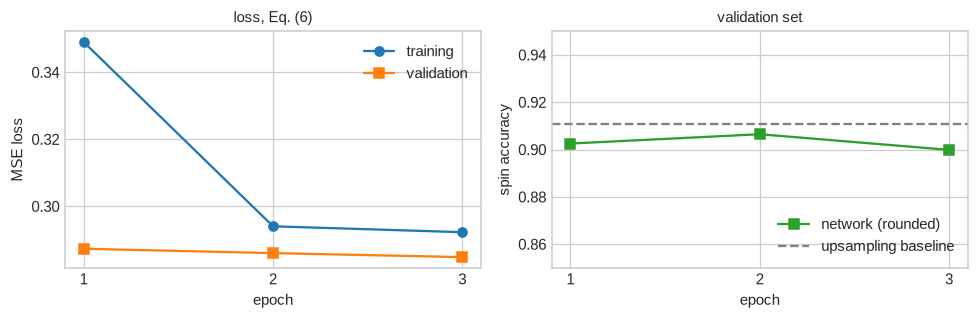

epoch 3/3 done after 231 s


In [13]:
def plot_history(history):
    clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(9, 3), dpi=110)
    ax[0].plot(history["epoch"], history["train"], "o-", label="training")
    ax[0].plot(history["epoch"], history["val"], "s-", label="validation")
    ax[0].set(xlabel="epoch", ylabel="MSE loss", title="loss, Eq. (6)")
    ax[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    ax[0].legend()
    ax[1].plot(history["epoch"], history["acc"], "s-", c="C2", label="network (rounded)")
    ax[1].axhline(acc_baseline, ls="--", c="gray", label="upsampling baseline")
    ax[1].set(xlabel="epoch", ylabel="spin accuracy", title="validation set", ylim=(0.85, 0.95))
    ax[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    ax[1].legend(loc="lower right")
    plt.tight_layout()
    plt.show()


cache = Path("_cache") / f"unet_L{L_fine}_beta{beta0}.pth"
history = dict(epoch=[], train=[], val=[], acc=[])

if use_pretrained and cache.exists():
    net.load_state_dict(torch.load(cache, map_location=torch_device))
    print(f"loaded {cache}")
else:
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)
    loss_fn = torch.nn.MSELoss()
    t_start = time.time()
    for epoch in range(1, epochs + 1):
        net.train()
        order = torch.randperm(len(X_train))
        running = 0.0
        for i in range(0, len(order), batch_size):
            idx = order[i:i + batch_size]
            optimizer.zero_grad()
            loss = loss_fn(net(X_train[idx].to(torch_device)), Y_train[idx].to(torch_device))
            loss.backward()
            optimizer.step()
            running += loss.item() * len(idx)

        field, spins = predict(net, coarse_val, mode="mean")
        history["epoch"].append(epoch)
        history["train"].append(running / len(order))
        history["val"].append(float(np.mean((field - fine_val) ** 2)))
        history["acc"].append(float(np.mean(spins == fine_val)))
        plot_history(history)
        print(f"epoch {epoch}/{epochs} done after {time.time() - t_start:.0f} s")
    cache.parent.mkdir(exist_ok=True)
    torch.save(net.state_dict(), cache)

Two remarks on the curves. The training loss is a running average over the epoch, during which the network is still improving, and is therefore higher than the validation loss evaluated at the end of the epoch. And after the first epoch the loss decreases only slowly: the network quickly learns what is easy to learn, namely where the domains are, while the remaining short-range detail is hard to predict (see Sec. V B).

## VII. USING THE LEARNED TRANSFORMATION

### A. One step on validation data

We first apply the trained network to the validation configurations. Every row of the figure shows one configuration: the coarse **input**, the continuous network **output** (red: close to $+1$, blue: close to $-1$; in all other panels white is $+1$ and black is $-1$), the two discretizations of Sec. VI B, and the true fine configuration.

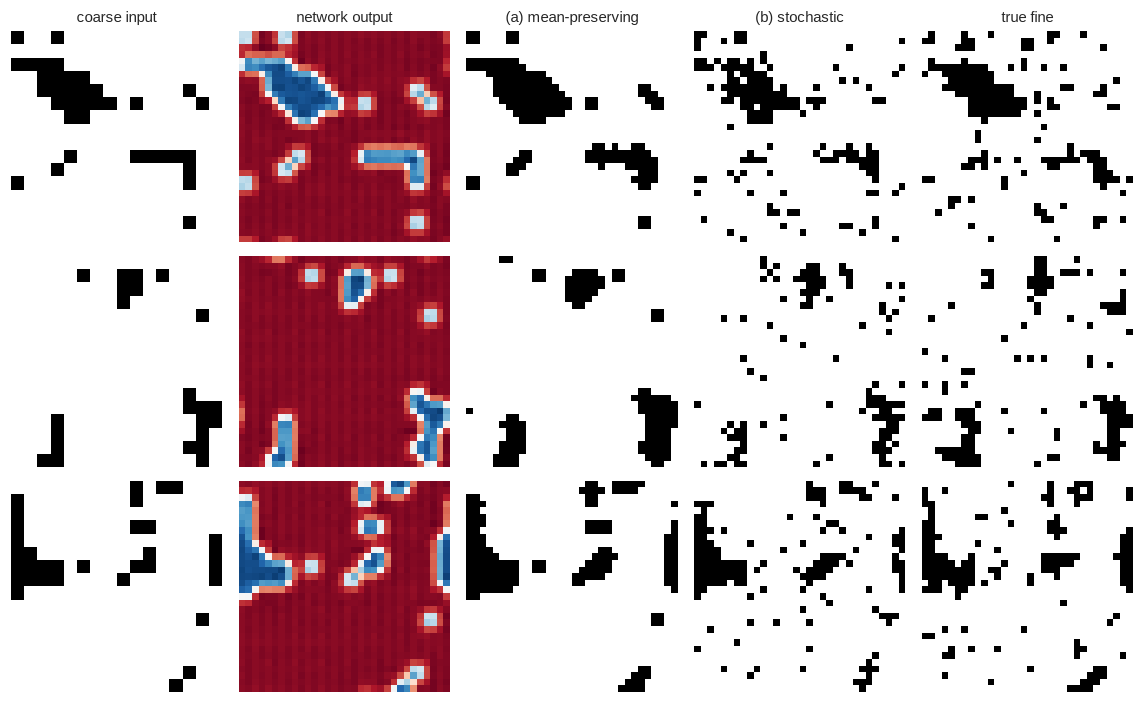

In [14]:
field_val, spins_mean = predict(net, coarse_val, mode="mean")
_, spins_sample = predict(net, coarse_val, mode="sample")

fig, axes = plt.subplots(3, 5, figsize=(10.5, 6.5))
titles = ["coarse input", "network output", "(a) mean-preserving", "(b) stochastic", "true fine"]
for row, i in enumerate([0, 1, 2]):
    images = [coarse_val[i], field_val[i], spins_mean[i], spins_sample[i], fine_val[i]]
    for col, (ax, img) in enumerate(zip(axes[row], images)):
        ax.imshow(img, cmap="RdBu_r" if col == 1 else "gray", vmin=-1, vmax=1, interpolation="nearest")
        ax.axis("off")
        if row == 0:
            ax.set_title(titles[col])
plt.tight_layout()
plt.show()

The continuous output is a smooth version of the fine configuration: it is nearly $\pm1$ inside large domains and close to $0$ in uncertain places. Both discretizations are faithful on the scale of the domains. They differ in the short-range structure: (a) draws the spins with the largest predicted values as connected clusters, whereas (b) leaves isolated flipped spins inside domains, like the true configuration does.

We now quantify this on all validation configurations. For each row of the table we compare with the true fine configuration: the spin accuracy, the mean $|m|$, the mean absolute error of $|m|$ per configuration, and the nearest-neighbour correlation $\langle s_i s_j \rangle$.

In [15]:
def compare(name, pred, truth):
    return {
        "spin accuracy": np.mean(pred == truth),
        "<|m|>": magnetization(pred).mean(),
        "mean |m - m_true|": np.mean(np.abs(magnetization(pred) - magnetization(truth))),
        "<s_i s_j>": nn_correlation(pred).mean(),
    }

table = pd.DataFrame({
    "true fine configurations": compare("true", fine_val, fine_val),
    "(a) mean-preserving rounding": compare("a", spins_mean, fine_val),
    "(b) stochastic rounding": compare("b", spins_sample, fine_val),
    "baseline: upsampling": compare("base", upsampled, fine_val),
}).T
table.round(4)

,spin accuracy,<|m|>,mean |m - m_true|,<s_i s_j>
true fine configurations,1.0000,0.6490,0.0000,0.7173
(a) mean-preserving rounding,0.8999,0.6473,0.0197,0.8425
(b) stochastic rounding,0.8570,0.6471,0.0232,0.6741
baseline: upsampling,0.9109,0.7031,0.0548,0.8546


> **Caveat:** Judged by spin accuracy the network does *not* beat the baseline: (a) is on par with it and (b) is clearly worse, because sampling adds noise to every spin. The other columns show what the accuracy misses: both roundings reproduce the magnetization far better than the baseline (which is too large, since the upsampled configurations keep the aligned coarse spins), whereas the short-range order separates them: (a) and the baseline are much too ordered, (b) is much closer, though still about 6% too low. Pointwise accuracy cannot see any of this.

### B. Iterating the transformation

Because the network is fully convolutional, the *same* weights can be applied to any lattice whose size is divisible by 4. We exploit this by feeding the output back as input: $L_\mathrm{fine}/2 \to L_\mathrm{fine} \to 2L_\mathrm{fine} \to 4L_\mathrm{fine}$. The input of the first step must be an **independent** ensemble of the small system, not the coarse-grained training configurations. We therefore simulate a fresh ensemble at $L_\mathrm{fine}/2$, wrapping the steps of Sec. IV into functions with their own random seed. Because $\tau_\mathrm{int}$ estimated from a finite pilot run is itself uncertain (by tens of percent for the larger lattices), the function equilibrates for at least $20\,\tau_\mathrm{int}$ sweeps and keeps one configuration every $3\,\tau_\mathrm{int}$ sweeps, i.e. more conservatively than in Sec. IV C.

In [16]:
def estimate_tau(L, beta, seed, n_sweeps=50_000, warmup=2_000):
    """Integrated autocorrelation time of |m| (in sweeps) from a pilot run."""
    sim = IsingModel(beta, L, seed=seed)
    m = np.empty(n_sweeps)
    for t in range(n_sweeps):
        sim.try_many_random_flips(L * L)
        m[t] = sim.magnetization()
    return autocorr.calc_error(np.abs(m[warmup:]))[2]


def sample_ensemble(L, beta, n, seed, tau):
    """n decorrelated configurations of the L x L model: an equilibration of at least 20 tau sweeps,
    then one configuration every 3 tau sweeps."""
    sim = IsingModel(beta, L, seed=seed)
    sim.try_many_random_flips(L * L * max(2_000, int(20 * tau)))
    spacing = int(np.ceil(3 * tau))
    configs = np.empty((n, L, L), dtype=np.int8)
    for i in range(n):
        for _ in range(spacing):
            sim.try_many_random_flips(L * L)
        configs[i] = sim.as_numpy()
    return configs


def generate(net, start, steps, mode):
    """Apply the inverse RG `steps` times. Returns the list of ensembles [start, start x2, ...]."""
    levels = [start]
    for _ in range(steps):
        levels.append(predict(net, levels[-1], mode=mode, batch=20)[1])
    return levels

In [17]:
sizes = [L_fine // 2 * 2**k for k in range(n_steps + 1)]          # 16, 32, 64, 128
timing = {}

tau_start = estimate_tau(sizes[0], beta0, seed=seed + 1)
t_start = time.time()
start = sample_ensemble(sizes[0], beta0, n_test, seed=seed + 100, tau=tau_start)
timing[("direct", sizes[0])] = (time.time() - t_start) / n_test
print(f"L = {sizes[0]}: tau_int = {tau_start:.1f} sweeps, {n_test} configurations in {time.time() - t_start:.0f} s")

generated = {}
for mode in ("mean", "sample"):
    t_start = time.time()
    generated[mode] = generate(net, start, n_steps, mode)
    print(f"generated {sizes[1:]} with rounding '{mode}' in {time.time() - t_start:.0f} s")

L = 16: tau_int = 57.7 sweeps, 200 configurations in 0 s


generated [32, 64, 128] with rounding 'mean' in 32 s


generated [32, 64, 128] with rounding 'sample' in 30 s


A single configuration on its way from $16\times16$ to $128\times128$, for both roundings:

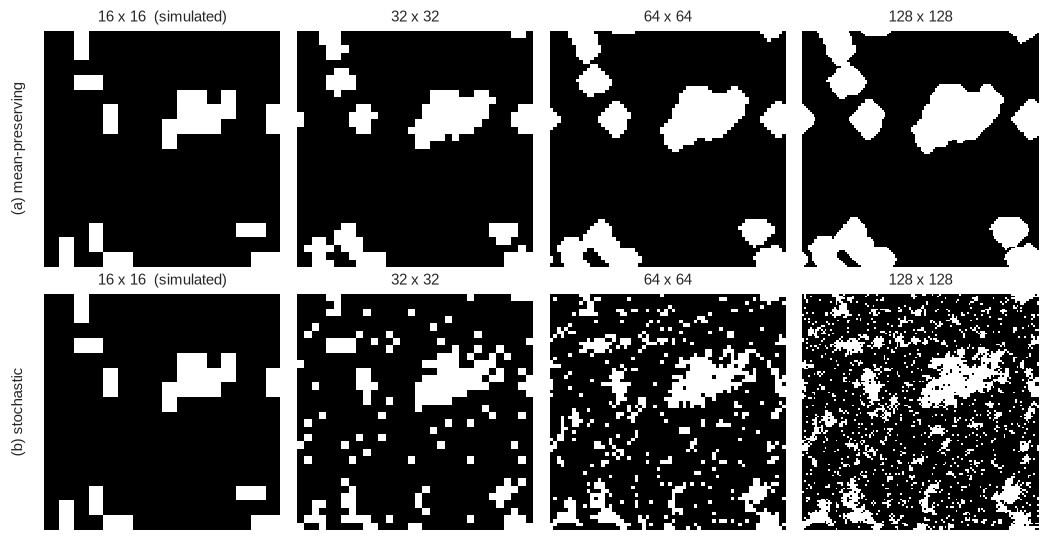

In [18]:
fig, axes = plt.subplots(2, len(sizes), figsize=(2.4 * len(sizes), 5))
for row, (mode, name) in enumerate([("mean", "(a) mean-preserving"), ("sample", "(b) stochastic")]):
    for col, L_ in enumerate(sizes):
        axes[row, col].imshow(generated[mode][col][0], cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
        axes[row, col].axis("off")
        axes[row, col].set_title(f"{L_} x {L_}" + ("  (simulated)" if col == 0 else ""))
    axes[row, 0].text(-0.08, 0.5, name, transform=axes[row, 0].transAxes, rotation=90, va="center", ha="right")
plt.tight_layout()
plt.show()

In both rows the large-scale domains are preserved from step to step. Row (a) mainly refines the domain boundaries, so the picture stays smooth at every size, while row (b) adds isolated spins and small clusters and thereby the multi-scale structure expected of a critical configuration (its noisy appearance at $128\\times128$ already hints at some excess disorder). Whether the *ensembles* are right is a question about statistics, which we turn to next.

## VIII. DOES IT REPRODUCE THE PHYSICS?

### A. Direct simulations for comparison

To judge the generated ensembles we need the truth. For the sizes where this is affordable we simulate independent ensembles directly, using `sample_ensemble` from above; these are the *test ensembles*. They use different random seeds than the training ensemble. The cost of this step, and its growth with $L$, is exactly what the inverse RG tries to avoid.

In [19]:
direct = {sizes[0]: start}
for L_ in sizes[1:3]:                                      # 32 and 64
    tau = estimate_tau(L_, beta0, seed=seed + 300 + L_)
    t_start = time.time()
    direct[L_] = sample_ensemble(L_, beta0, n_test, seed=seed + 200 + L_, tau=tau)
    timing[("direct", L_)] = (time.time() - t_start) / n_test
    print(f"L = {L_}: tau_int = {tau:.0f} sweeps, {n_test} configurations in {time.time() - t_start:.0f} s")

L = 32: tau_int = 116 sweeps, 200 configurations in 3 s


L = 64: tau_int = 1166 sweeps, 200 configurations in 126 s


### B. Observables

For every size we compute the ensemble means of $|m|$ and of the nearest-neighbour correlation, with the standard error of the mean. (The configurations of one ensemble are decorrelated by construction, so the naive error is appropriate.) For reference, the exact nearest-neighbour correlation of the infinite lattice at $\beta_c$ is $\langle s_i s_j \rangle = 1/\sqrt2 \approx 0.707$.

In [20]:
def summarize(configs):
    m = magnetization(configs)
    c = nn_correlation(configs)
    return m.mean(), m.std() / np.sqrt(len(m)), c.mean()


rows = []
for k, L_ in enumerate(sizes):
    for label, source in (("direct simulation", direct.get(L_)),
                          ("(a) mean-preserving", generated["mean"][k] if k > 0 else None),
                          ("(b) stochastic", generated["sample"][k] if k > 0 else None)):
        if source is not None:
            m_mean, m_err, corr = summarize(source)
            rows.append(dict(L=L_, ensemble=label, m=f"{m_mean:.3f} +- {m_err:.3f}", nn_corr=round(corr, 4)))
pd.DataFrame(rows).rename(columns={"m": "<|m|>", "nn_corr": "<s_i s_j>"}).set_index(["L", "ensemble"])

<|m|>  <s_i s_j>
L   ensemble                                      
16  direct simulation    0.702 +- 0.015     0.7255
32  direct simulation    0.652 +- 0.012     0.7141
    (a) mean-preserving  0.645 +- 0.013     0.8479
    (b) stochastic       0.645 +- 0.014     0.6802
64  direct simulation    0.597 +- 0.011     0.7094
    (a) mean-preserving  0.591 +- 0.012     0.9126
    (b) stochastic       0.595 +- 0.013     0.6621
128 (a) mean-preserving  0.539 +- 0.011     0.9514
    (b) stochastic       0.549 +- 0.012     0.6522

Two things stand out (numbers are those of the run stored in this notebook, see the output above):

* **The magnetization is reproduced.** For *both* roundings the generated $\langle|m|\rangle$ agrees within the statistical errors with the direct simulations at all sizes where we have one ($L=32$ and $64$). The *distribution* of $|m|$ agrees as well, see Sec. VIII C, apart from a slightly missing tail at the largest values.
* **The short-range order is not.** Deterministic rounding (a) makes the configurations too ordered: $\langle s_i s_j\rangle$ rises from 0.85 at $L=32$ to 0.95 at $L=128$, while the true value is about 0.71 at all sizes, so the error *grows* with every application of the network. Stochastic rounding (b) stays much closer (0.68, 0.66, 0.65) but is also 5 to 8 % too low and drifts slowly towards too disordered configurations.

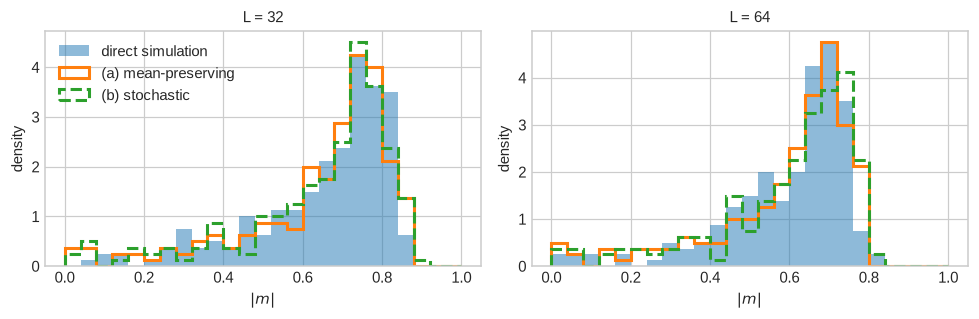

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, k in zip(axes, [1, 2]):
    L_ = sizes[k]
    bins = np.linspace(0, 1, 26)
    ax.hist(magnetization(direct[L_]), bins, density=True, alpha=0.5, label="direct simulation")
    ax.hist(magnetization(generated["mean"][k]), bins, density=True, histtype="step", lw=2, label="(a) mean-preserving")
    ax.hist(magnetization(generated["sample"][k]), bins, density=True, histtype="step", lw=2, ls="--", label="(b) stochastic")
    ax.set(xlabel=r"$|m|$", ylabel="density", title=f"L = {L_}")
axes[0].legend()
plt.tight_layout()
plt.show()

### D. Finite-size scaling: extracting $\beta/\nu$

The strongest test is Eq. (4): at (close to) $\beta_c$ the mean magnetization must fall off as $L^{-\beta/\nu}$ with $\beta/\nu = 1/8$. We fit a straight line to $\ln\langle|m|\rangle$ versus $\ln L$ for the generated ensembles (including the simulated starting size), and for comparison for the direct simulations.

direct simulation    beta/nu = 0.117 +- 0.020   (exact: 0.125)
(a) mean-preserving  beta/nu = 0.126 +- 0.014   (exact: 0.125)
(b) stochastic       beta/nu = 0.118 +- 0.014   (exact: 0.125)


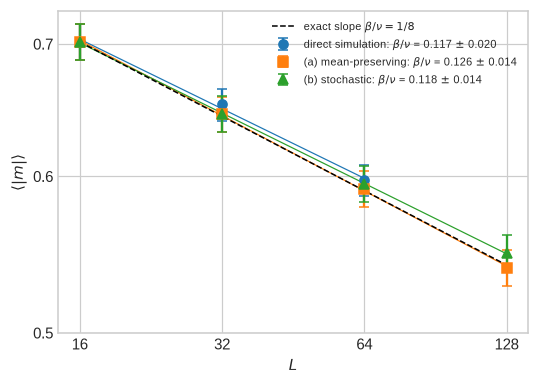

In [22]:
def fit_exponent(Ls, means, errors):
    """Weighted straight-line fit of ln<|m|> versus ln L. Returns beta/nu and its statistical error."""
    x, y = np.log(Ls), np.log(means)
    sigma = np.maximum(np.asarray(errors) / np.asarray(means), 1e-3)     # guard against zero errors
    coef, cov = np.polyfit(x, y, 1, w=1 / sigma, cov="unscaled")
    return -coef[0], np.sqrt(cov[0, 0]), coef


stats = {
    "direct simulation": [summarize(direct[L_]) for L_ in sizes if L_ in direct],
    "(a) mean-preserving": [summarize(generated["mean"][k]) for k in range(len(sizes))],
    "(b) stochastic": [summarize(generated["sample"][k]) for k in range(len(sizes))],
}
Ls = {"direct simulation": [L_ for L_ in sizes if L_ in direct]}
Ls["(a) mean-preserving"] = Ls["(b) stochastic"] = sizes

fig, ax = plt.subplots(figsize=(5, 3.6))
style = {"direct simulation": ("o", "C0"), "(a) mean-preserving": ("s", "C1"), "(b) stochastic": ("^", "C2")}
for name, values in stats.items():
    means, errs = np.array([v[0] for v in values]), np.array([v[1] for v in values])
    exponent, error, coef = fit_exponent(Ls[name], means, errs)
    marker, color = style[name]
    print(f"{name:20s} beta/nu = {exponent:.3f} +- {error:.3f}   (exact: {BETA_OVER_NU})")
    ax.errorbar(Ls[name], means, yerr=errs, fmt=marker, c=color, capsize=3, label=fr"{name}: $\beta/\nu$ = {exponent:.3f} $\pm$ {error:.3f}")
    ax.plot(Ls[name], np.exp(coef[1]) * np.array(Ls[name], dtype=float) ** coef[0], c=color, lw=0.8)
ref = stats["direct simulation"][0][0] * (np.array(sizes) / sizes[0]) ** (-BETA_OVER_NU)
ax.plot(sizes, ref, "k--", lw=1, label=r"exact slope $\beta/\nu = 1/8$")
ax.set(xscale="log", yscale="log", xlabel="$L$", ylabel=r"$\langle |m| \rangle$")
ax.set_xticks(sizes)
ax.set_xticklabels(sizes)
ax.set_yticks([0.5, 0.6, 0.7])
ax.set_yticklabels(["0.5", "0.6", "0.7"])
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_formatter(NullFormatter())
ax.legend(fontsize=7.5)
plt.tight_layout()
plt.show()

In this run all three estimates are compatible with the exact value $1/8$: $\beta/\nu = 0.126 \pm 0.014$ for the generated ensembles with rounding (a), $0.118 \pm 0.014$ with rounding (b), and $0.117 \pm 0.020$ from the direct simulations, which are limited to $L \le 64$. The magnetization decreases with $L$ as it should, and the generated ensembles extend the range to $L=128$ at no simulation cost.

> **Caveat:** The quoted errors are purely statistical and *optimistic*. The generated ensembles at different sizes all descend from the same starting configurations, so their errors are correlated and the fit error is underestimated. The result also depends on the (single) training run: the thesis averages over nine independently trained networks to include this variation. Finally, $\beta_0 = 0.44$ is slightly off $\beta_c = 0.4407$, so small systematic deviations from a pure power law are expected.

### E. Cost

The motivation of the method is cost. The table lists the wall-clock time per configuration of the direct simulation (equilibration and decorrelation, excluding the short pilot run that estimates $\tau_\mathrm{int}$) and, for the sizes where it applies, of one application of the network, both measured in this notebook on the same machine. It is an illustration, not a benchmark: it neglects the (one-time) cost of the training, and the comparison depends strongly on the hardware.

In [23]:
network_time = {}
for k, L_ in enumerate(sizes[1:], start=1):
    x = generated["mean"][k - 1][:10]
    t_start = time.time()
    predict(net, x, mode="mean", batch=10)
    network_time[L_] = (time.time() - t_start) / len(x)

cost = pd.DataFrame({
    "direct simulation [s / config]": {L_: timing.get(("direct", L_), np.nan) for L_ in sizes},
    "one network step to this size [s / config]": {L_: network_time.get(L_, np.nan) for L_ in sizes},
})
cost.index.name = "L"
cost.round(4)

,direct simulation [s / config],one network step to this size [s / config]
L,,
16,0.0025,NaN
32,0.0174,0.0096
64,0.6304,0.0276
128,NaN,0.1054


The direct simulation becomes rapidly more expensive with $L$ (critical slowing down plus more spins per sweep; the steep increase up to $L=64$ is partly noise, because $\tau_\mathrm{int}$ was estimated from a finite pilot run, see the values printed above), while the network cost per configuration grows roughly with the number of sites, by a factor of 3 to 4 per doubling. The direct simulation of $128\times128$ was not attempted here.

## IX. SUMMARY AND OUTLOOK

We went through the complete pipeline: a Metropolis ensemble, its autocorrelation analysis, majority-rule coarse-graining, supervised training of a U-Net on (coarse, fine) pairs, and repeated application of the learned map to generate configurations on lattices that were never simulated. The main observations, for the run stored in this notebook:

**What worked.** With about four minutes of training on a single CPU core, the learned inverse transformation reproduces the magnetization of the direct simulations (mean and distribution) for both discretizations, and yields finite-size-scaling exponents compatible with the exact $\beta/\nu = 1/8$, from lattices up to $128\times128$.

**What did not.** Pointwise reconstruction is limited by the information that the majority rule destroys, and the short-range order of the generated configurations is wrong for the mean-preserving rounding used in the thesis. Our stochastic rounding is much better in this respect but 5 to 8 % too disordered, and it drifts with the number of iterations; a proper treatment of the conditional distribution would need a generative model. This also means that the good magnetization results say little about the quality of the local structure.

**How to go further.**

* *Scale up.* The thesis trained on 5000 simulated configurations of size $32\times32$ at $\beta_0=0.44$ (augmented to 20,000 by rotations), for several hundred epochs with batch size 2, and used nine independently trained networks. The command-line tool `scripts/train.py` does this, with the same `UNet` (the thesis states batch size 2, while the default of the script is 1; see `--batch-size`).
* *Beyond $\beta_0$.* The thesis uses the energies of the small ensemble to *reweight* the generated observables to neighbouring $\beta$ and extracts $\beta_c$, $\beta/\nu$ and $\gamma/\nu$ from them (`scripts/analyze_inverseRG.py`).
* *Explore.* Change `beta0`, `n_configs`, `epochs` or `alpha` in Sec. III B, or replace `UNet` by `DeepCNN` from `invrg.models`.